## EPMT Play

We're trying to query EPMT Data into a simple csv file. The focus of this notebook is the EPMT_JOB_TAGS annotations for now, but the data will eventually be expanded. A little bit of visualization is also added to the end.

In [2]:
# Environment work around to get matplotlib/seaborn
import sys
sys.path.append('/home/Janice.Kim/work/epmt/misc/jk_py37')

In [3]:
import epmt_query as eq

In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import csv
import pandas as pd
from pprint import pprint

In [5]:
def parse_annotations(annotations: str):
    """"                                                                                                                                                                                                           
    Returns dict parsed from the annotations string                                                                                                                                                                
    """
    result = {}
    for pair in annotations.split(";"):
        key, val = pair.split(":", 1) # Take the first colon. Assumption: There shouldn't be more than one.                                                                                                        
        result[key.strip()] = val.strip()
    return result

In [18]:
all_jobs = eq.get_jobs(fmt='dict', limit=100) # TODO: increase limit once things look okay.                                                                                                                     
data = []
for job in all_jobs:
    row = parse_annotations(job['annotations']['EPMT_JOB_TAGS'])
    row['cpu_time'] = job['cpu_time']
    data.append(row)

print(f"Writing {len(data)} rows.")
labels = data[0].keys()

Writing 100 rows.


Ask Ian or Avery: Is it normal to expect the EPMT_JOB_TAGS to have different keys for each for? Sometimes the labels are different depending on which rows I'm looking at. 

In [19]:
#for d in data:
#    pprint(d)

{'cpu_time': 103951272.0,
 'exp_component': 'river_cubic',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'SPEAR_c384_OM4p08_Control_1990_A13',
 'exp_platform': 'gfdl.ncrc5-intel23_2_0',
 'exp_seg_months': '12',
 'exp_target': 'repro-openmp',
 'exp_time': '01000101',
 'script_name': 'SPEAR_c384_OM4p08_Control_1990_A13_river_cubic_01000101'}
{'cpu_time': 12713067.0,
 'exp_component': 'atmos_scalar',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'SPEAR_c384_OM4p08_Control_1990_A13',
 'exp_platform': 'gfdl.ncrc5-intel23_2_0',
 'exp_seg_months': '12',
 'exp_target': 'repro-openmp',
 'exp_time': '01000101',
 'script_name': 'SPEAR_c384_OM4p08_Control_1990_A13_atmos_scalar_01000101'}
{'cpu_time': 22186898.0,
 'exp_component': 'ocean_scalar',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'SPEAR_c384_OM4p08_Control_1990_A13',
 'exp_platform': 'gfdl.ncrc5-intel23_2_0',
 'exp_seg_months': '12',
 'exp_target': 'repr

 'exp_seg_months': '12',
 'exp_target': 'prod',
 'exp_time': '19910101',
 'script_name': 'Simple_spinup_river_year_19910101'}
{'cpu_time': 29016439.0,
 'exp_component': 'river_year_inst',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'Simple_spinup',
 'exp_platform': 'gfdl.ncrc6-intel23-classic',
 'exp_seg_months': '12',
 'exp_target': 'prod',
 'exp_time': '19910101',
 'script_name': 'Simple_spinup_river_year_inst_19910101'}
{'cpu_time': 36401881.0,
 'exp_component': 'atmos_forcing',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'Simple_spinup',
 'exp_platform': 'gfdl.ncrc6-intel23-classic',
 'exp_seg_months': '12',
 'exp_target': 'prod',
 'exp_time': '19910101',
 'script_name': 'Simple_spinup_atmos_forcing_19910101'}
{'cpu_time': 50574934.0,
 'exp_component': 'atmos',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'Simple_spinup',
 'exp_platform': 'gfdl.ncrc6-intel23-classic',
 'exp_seg_months': '12',
 

 'script_name': 'om5_b12_brineplume_mldfac2_ocean_Mozambique_Channel_19820101'}
{'cpu_time': 36178927.0,
 'exp_component': 'ocean_Drake_Passage',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'om5_b12_brineplume_mldfac2',
 'exp_platform': 'gfdl.ncrc5-intel23',
 'exp_seg_months': '12',
 'exp_target': 'prod',
 'exp_time': '19820101',
 'script_name': 'om5_b12_brineplume_mldfac2_ocean_Drake_Passage_19820101'}
{'cpu_time': 35170606.0,
 'exp_component': 'ocean_Taiwan_Luzon',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'om5_b12_brineplume_mldfac2',
 'exp_platform': 'gfdl.ncrc5-intel23',
 'exp_seg_months': '12',
 'exp_target': 'prod',
 'exp_time': '19820101',
 'script_name': 'om5_b12_brineplume_mldfac2_ocean_Taiwan_Luzon_19820101'}
{'cpu_time': 35222656.0,
 'exp_component': 'ocean_Faroe_Scotland',
 'exp_fre_mod': '/home/fms/local/opt/fre-commands/bronx-23',
 'exp_name': 'om5_b12_brineplume_mldfac2',
 'exp_platform': 'gfdl.ncrc5-intel23'

In [21]:
with open("/home/Janice.Kim/work/epmt/jk_data_play.csv", "w") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=labels)
    writer.writeheader()
    writer.writerows(data)

## Look at the Data and Visualize a Bit

Now, let's see what we have and try to visualize a little of the data.

In [30]:
csv_path = "/home/Janice.Kim/work/epmt/jk_data_play.csv"
target_col = "cpu_time" # ground truth column

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("Columns:\n", df.dtypes)

Shape: (100, 9)
Columns:
 exp_component      object
exp_fre_mod        object
exp_name           object
exp_time            int64
exp_platform       object
exp_target         object
exp_seg_months      int64
script_name        object
cpu_time          float64
dtype: object


In [31]:
df.head()

,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name,cpu_time
0,river_cubic,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_river_cubic...,103951272.0
1,atmos_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,1000101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_atmos_scala...,12713067.0
2,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ocean_scala...,22186898.0
3,ocean_daily_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ocean_daily...,5032113.0
4,ice_1deg,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Control_1990_A13,990101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Control_1990_A13_ice_1deg_00...,72152950.0


In [32]:
df.describe()

,exp_time,exp_seg_months,cpu_time
count,1.000000e+02,100.0,1.000000e+02
mean,1.045550e+07,12.0,4.181445e+07
std,8.965997e+06,0.0,3.050133e+07
min,2.901010e+05,12.0,3.289016e+06
25%,1.100101e+06,12.0,1.910443e+07
50%,4.410101e+06,12.0,3.483267e+07
75%,1.982010e+07,12.0,6.275514e+07
max,1.995010e+07,12.0,1.289305e+08


In [33]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 3
# category columns: 6


Text(0.5, 0.98, 'Numeric Feature Distributions')

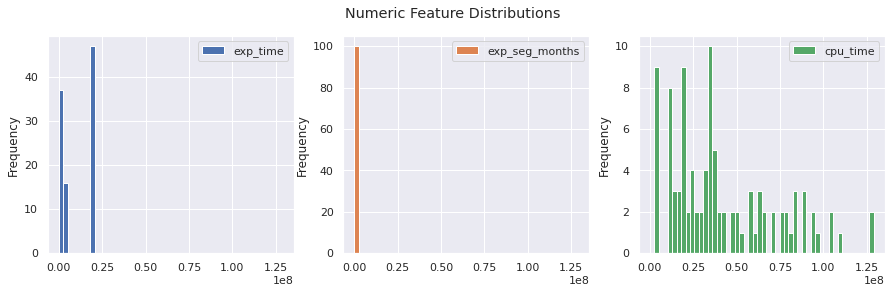

In [56]:
axes = df[numeric_cols].plot(kind='hist', bins=50, subplots=True, layout=(1,3), figsize=(15,4))
plt.suptitle("Numeric Feature Distributions")